In [42]:
from lsst.meas.algorithms import LoadReferenceObjectsConfig, ReferenceObjectLoader
from lsst.daf.butler import Butler, Quantum
from lsst.pipe.base import QuantumContext
from lsst.pipe.tasks.coaddBase import makeSkyInfo
from lsst.sphgeom import IntersectionRegion, Region, Circle, LonLat, Angle, UnitVector3d, UnionRegion
from lsst.sphgeom import HtmPixelization
from lsst.skymap import Index2D, makeSkyPolygonFromBBox

import lsst.geom

import matplotlib.pyplot as plt
import numpy as np

from itertools import product, combinations
from matplotlib.patches import Ellipse, Polygon

In [3]:
def mag_to_radius(mag):
    """Convert GAIA g-band magnitude to radius (in radians).
    """
    mag = np.asarray(mag, dtype=np.float64)
    return np.select(
        [mag <= 11.0, mag <= 14.0],
        np.array([450, 200.0]) * 0.2 * np.pi / (180 * 60 * 60),  # 450 & 200 px
        default=0.0,
    )

Text(0, 0.5, 'Radii [arcmin]')

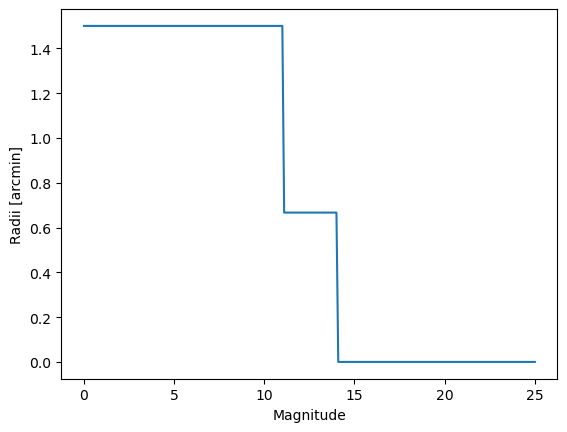

In [12]:
mags = np.linspace(0, 25, 251)
radii = mag_to_radius(mags) * 180 * 60 / np.pi
plt.plot(mags, radii)
plt.xlabel("Magnitude")
plt.ylabel("Radii [arcmin]")

In [10]:
ref_loader_config = LoadReferenceObjectsConfig()

# pixelMargin has to be at least the size of the maximum pixel_radius.
ref_loader_config.pixelMargin = 450  # arbitrary for demo purposes

# AB magnitude from nJy flux: mag = -2.5*log10(flux_nJy) + 31.4
AB_ZP_NJY = 31.4

In [5]:
butler = Butler("dp2_prep", collections=["LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage3"])
skyMap = butler.get("skyMap", skymap="lsst_cells_v2")

In [6]:
tractId = 9813  # COSMOS field

In [7]:
tractInfo = skyMap[tractId]
wcs = tractInfo.getWcs()

# Bounding box for the tract, expanded by pixelMargin on all sides.
bbox = lsst.geom.Box2D(tractInfo.getBBox())
bbox.grow(ref_loader_config.pixelMargin)

tracts = []

# Convert each corner (pixel coords) to sky, then find the tract there.
corners = bbox.getCorners()
for corner in corners:
    coord = wcs.pixelToSky(corner)
    tract = skyMap.findTract(coord)
    tracts.append(tract.getId())

for corner1, corner2 in combinations(corners, 2):
    eval_point = lsst.geom.Point2D(
        0.5 * (corner1.x + corner2.x),
        0.5 * (corner1.y + corner2.y),
    )
    coord = wcs.pixelToSky(eval_point)
    tract = skyMap.findTract(coord)
    tracts.append(tract.getId())
    
print(tracts)

[9571, 9570, 10054, 10056, 9570, 9813, 9814, 9812, 9813, 10055]


In [9]:
assert tractId - 1 in tracts
assert tractId + 1 in tracts
assert len(set(tracts)) >= 8

In [8]:
ref_cat_refs = butler.query_datasets("the_monster_20250219", where=f"skymap='lsst_cells_v2' AND tract IN {tuple(set(tracts))}")
print("Number of reference catalogs (htm7 regions) considered = ", len(ref_cat_refs))

Number of reference catalogs (htm7 regions) considered =  111


In [24]:
# ReferenceObjectLoader.loadRegion accesses `dataId.region` as an *attribute*
# (dataId.region.intersects(region)), so region must be a property, not a method.
# the_monster is sharded on htm7, so each ref's region is its HTM level-7 trixel.
class MyDataCoordinate:
    _htm = HtmPixelization(7)

    def __init__(self, ref):
        self._htm7 = ref.dataId["htm7"]

    @property
    def region(self):
        return self._htm.pixel(self._htm7)


# One MyDataCoordinate per ref, in the same order as refCats so the loader's
# zip(self.dataIds, self.refCats) pairs each ref with its correct region.
dataIds = [MyDataCoordinate(ref) for ref in ref_cat_refs]

# loadRegion calls refCat.get(), so refCats must be *deferred* dataset handles,
# not bare DatasetRefs (which have no .get()).
refCats = [butler.getDeferred(ref) for ref in ref_cat_refs]

ref_loader = ReferenceObjectLoader(
    dataIds=dataIds,
    refCats=refCats,
    name="the_monster_20250219",
    config=ref_loader_config,
)

In [27]:
# Load reference objects over the tract, expanded by pixelMargin.
# loadPixelBox(bbox, wcs, filterName, ...) converts the pixel box to a sphere
# region internally and pulls every shard (via dataId.region) that overlaps.
loadBBox = lsst.geom.Box2I(tractInfo.getBBox())

result = ref_loader.loadPixelBox(
    bbox=loadBBox,
    wcs=wcs,
    filterName="phot_g_mean",   # -> phot_g_mean_flux
)
refCat = result.refCat

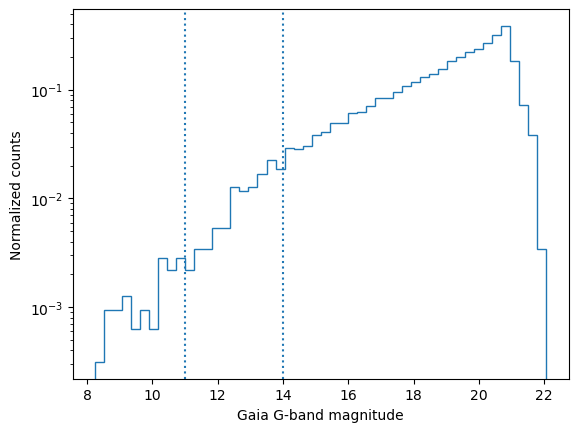

In [32]:
mags = -2.5 * np.log10(refCat["phot_g_mean_flux"]) + AB_ZP_NJY
plt.hist(mags, bins=50, density=True, histtype="step")
plt.yscale("log")
plt.xlabel("Gaia G-band magnitude")
plt.ylabel("Normalized counts")

plt.axvline(11.0, ls=':')
plt.axvline(14.0, ls=':')

In [41]:
# Radius per refCat row, from its phot_g_mean_flux -> AB mag -> mag_to_radius.
ra = np.asarray(refCat["coord_ra"])    # radians
dec = np.asarray(refCat["coord_dec"])  # radians
flux = np.asarray(refCat[result.fluxField])  # nJy

good = np.isfinite(flux) & (flux > 0)
mag = np.full(len(refCat), np.inf)
mag[good] = -2.5 * np.log10(flux[good]) + AB_ZP_NJY

radius = mag_to_radius(mag)  # opening angle in radians

union = UnionRegion(*(
    Circle(UnitVector3d(LonLat.fromRadians(ra[i], dec[i])), Angle(radius[i]))
    for i in range(len(radius))
    if radius[i] > 0
))
print("Number of circles (radius > 0):", len(union.getRegions(union)))

Number of circles (radius > 0): 404


In [43]:
def bbox_to_radec(bbox):
    """Corners of a pixel Box2I/Box2D as an (N,2) array of (RA, Dec) in degrees."""
    return np.array(
        [[c.getLongitude().asDegrees(), c.getLatitude().asDegrees()]
         for c in (wcs.pixelToSky(p) for p in lsst.geom.Box2D(bbox).getCorners())]
    )
    
def plot_bright_star_masks(tractInfo, union):
    poly_radec = bbox_to_radec(tractInfo.getBBox())
    
    fig, ax = plt.subplots(figsize=(9, 9))
    
    # Patch and cell boundaries, lighter lines underneath.
    for patchInfo in tractInfo:
        ax.add_patch(Polygon(bbox_to_radec(patchInfo.outer_bbox), closed=True,
                             fill=False, edgecolor="0.6", lw=0.4, zorder=1))
        nc = patchInfo.getNumCells()
        for i in range(nc.x * nc.y):
            cbbox = patchInfo.getCellInfo(i).outer_bbox
            ax.add_patch(Polygon(bbox_to_radec(cbbox), closed=True,
                                 fill=False, edgecolor="0.85", lw=0.2, zorder=0))
    
    # Tract boundary.
    ax.add_patch(Polygon(poly_radec, closed=True, fill=False,
                         edgecolor="tab:blue", lw=2, label="tract bbox", zorder=3))
    
    # One ellipse per refCat circle; width scaled by 1/cos(dec) to look round.
    circles = union.getRegions(union)
    for circ in circles:
        center = LonLat(circ.getCenter())
        ra_c = center.getLon().asDegrees()
        dec_c = center.getLat().asDegrees()
        rad_deg = circ.getOpeningAngle().asDegrees()
        ax.add_patch(Ellipse((ra_c, dec_c),
                             width=2 * rad_deg / np.cos(np.radians(dec_c)),
                             height=2 * rad_deg,
                             fill=False, edgecolor="tab:red", lw=0.5, alpha=0.6, zorder=2))
    
    ra_min, ra_max = poly_radec[:, 0].min(), poly_radec[:, 0].max()
    dec_min, dec_max = poly_radec[:, 1].min(), poly_radec[:, 1].max()
    pad_ra = 0.1 * (ra_max - ra_min)
    pad_dec = 0.1 * (dec_max - dec_min)
    ax.set_xlim(ra_max + pad_ra, ra_min - pad_ra)  # RA increases to the left
    ax.set_ylim(dec_min - pad_dec, dec_max + pad_dec)
    
    ax.set_xlabel("RA [deg]")
    ax.set_ylabel("Dec [deg]")
    ax.set_title(f"Tract {tractId}: bbox + {len(circles)} mask circles")
    ax.set_aspect(1.0 / np.cos(np.radians(poly_radec[:, 1].mean())))
    plt.tight_layout()
    plt.show()

    return fig, ax

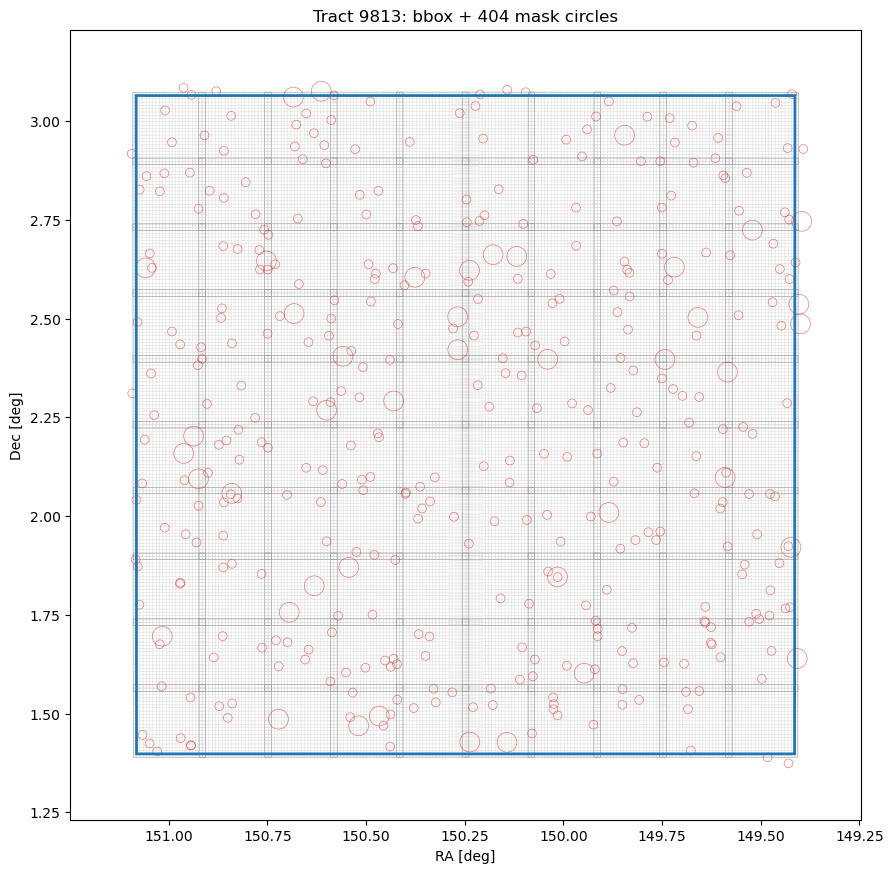

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Tract 9813: bbox + 404 mask circles'}, xlabel='RA [deg]', ylabel='Dec [deg]'>)

In [44]:
plot_bright_star_masks(tractInfo, union)

In [45]:
def iter_overlapping_cells(tractInfo, region):
    """Yield (patchId, cellId, overlap) for every cell whose outer sky polygon
    touches `region`. `overlap` is "full" if the cell lies entirely within the
    region, else "partial". patchId/cellId are sequential integer indices.

    Partial overlaps ARE reported (yielded with overlap="partial").
    """
    for patchInfo in tractInfo:
        # Prune whole patches that don't overlap.
        # We are being hopeful here.
        if patchInfo.inner_sky_polygon.isDisjointFrom(region):
            continue
        patchId = patchInfo.index
        # We loop over only the inner cells.
        for cx, cy in product(range(1, 22), range(1, 22)):
            cellId = Index2D(cx, cy)
            cellInfo = patchInfo.getCellInfo(cellId)
            poly = makeSkyPolygonFromBBox(cellInfo.inner_bbox.dilatedBy(50), cellInfo.wcs)
            if poly.isDisjointFrom(region):
                continue
            overlap = "full" if poly.isWithin(region) else "partial"
            yield patchId, cellId, overlap

In [46]:
overlaps = iter_overlapping_cells(tractInfo, union)

In [48]:
for num, row in enumerate(overlaps):
    print(row)
    if num > 20:
        break

(Index2D(x=0, y=0), Index2D(x=5, y=1), 'partial')
(Index2D(x=0, y=0), Index2D(x=5, y=2), 'partial')
(Index2D(x=0, y=0), Index2D(x=5, y=3), 'partial')
(Index2D(x=0, y=0), Index2D(x=5, y=4), 'partial')
(Index2D(x=0, y=0), Index2D(x=5, y=5), 'partial')
(Index2D(x=0, y=0), Index2D(x=6, y=1), 'partial')
(Index2D(x=0, y=0), Index2D(x=6, y=2), 'partial')
(Index2D(x=0, y=0), Index2D(x=6, y=3), 'partial')
(Index2D(x=0, y=0), Index2D(x=6, y=4), 'partial')
(Index2D(x=0, y=0), Index2D(x=6, y=5), 'partial')
(Index2D(x=0, y=0), Index2D(x=6, y=20), 'partial')
(Index2D(x=0, y=0), Index2D(x=6, y=21), 'partial')
(Index2D(x=0, y=0), Index2D(x=7, y=1), 'partial')
(Index2D(x=0, y=0), Index2D(x=7, y=2), 'partial')
(Index2D(x=0, y=0), Index2D(x=7, y=3), 'partial')
(Index2D(x=0, y=0), Index2D(x=7, y=19), 'partial')
(Index2D(x=0, y=0), Index2D(x=7, y=20), 'partial')
(Index2D(x=0, y=0), Index2D(x=7, y=21), 'partial')
(Index2D(x=0, y=0), Index2D(x=8, y=1), 'partial')
(Index2D(x=0, y=0), Index2D(x=8, y=2), 'parti

In [52]:
def get_all_circles():
    for ref in ref_cat_refs:
        cat = butler.get(ref)
        ra = np.asarray(cat["coord_ra"])      # radians
        dec = np.asarray(cat["coord_dec"])    # radians
        flux = np.asarray(cat["phot_g_mean_flux"])  # nJy
    
        # Only positive, finite fluxes yield a valid magnitude.
        good = np.isfinite(flux) & (flux > 0)
        mag = np.full(len(cat), np.inf)
        mag[good] = -2.5 * np.log10(flux[good]) + AB_ZP_NJY
    
        radius = mag_to_radius(mag)  # opening angle in radians
    
        for i in np.where(radius > 0)[0]:
            center = UnitVector3d(LonLat.fromRadians(ra[i], dec[i]))
            yield Circle(center, Angle(radius[i]))

union_without_refobj = UnionRegion(*get_all_circles())
print("Number of circles (radius > 0):", len(UnionRegion.getRegions(union_without_refobj)))

Number of circles (radius > 0): 3913


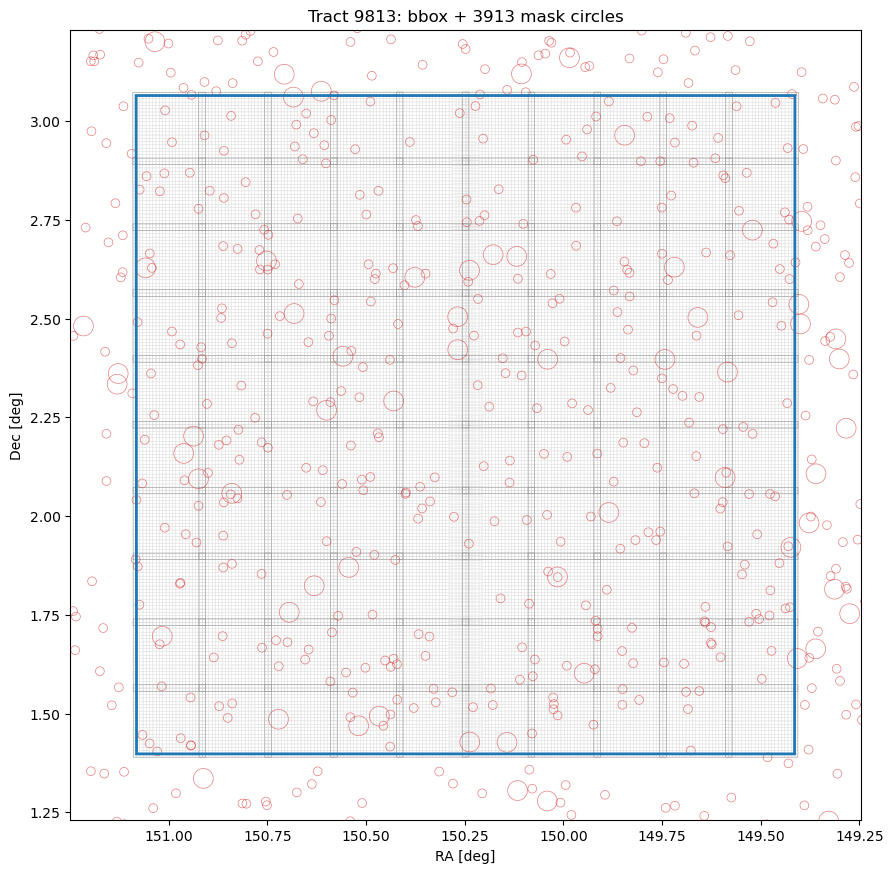

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Tract 9813: bbox + 3913 mask circles'}, xlabel='RA [deg]', ylabel='Dec [deg]'>)

In [53]:
plot_bright_star_masks(tractInfo, union_without_refobj)

In [54]:
assert list(iter_overlapping_cells(tractInfo, union)) == list(iter_overlapping_cells(tractInfo, union_without_refobj))